# Baseline — XGBoost

Ensemble de árvores (gradient boosting). Mesmos dados/split/CV do `data_prep` (`FarmStratifiedSplit`, 5 folds de 49 de teste por fazenda) e `leave_one_property_out`, via `sk_eval` — comparação justa com a DNN. Árvores não precisam de escala.

## 1. Setup

In [1]:
import os, sys
while not os.path.isdir("support_scripts"):
    os.chdir("..")
sys.path.append("support_scripts")

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from itertools import product
from xgboost import XGBRegressor
import data_prep as dp
import sk_eval

## 2. Dados

In [2]:
d = dp.get_data()
df, groups = d["df"], d["groups"]
print(f"{len(df)} animais | {len(d['feature_cols'])} preditores")
print("grupos:", groups.value_counts().to_dict())

245 animais | 9 preditores
grupos: {'elvis': 174, 'humberto': 71}


## 3. Grid search (5 folds de 49 de teste)

Seleção pela melhor R² média nos 5 folds — mesmo critério do grid da DNN. Guarda a config em uma lista de dicts (não em DataFrame) para não perder o tipo dos hiperparâmetros na hora de reconstruir o melhor modelo.

In [3]:
GRID = dict(
    n_estimators=[200, 400],
    max_depth=[2, 3, 4],
    learning_rate=[0.03, 0.1],
    subsample=[0.8, 1.0],
    min_child_weight=[1, 5],
)
keys = list(GRID)
cfgs, rows = [], []
for vals in product(*GRID.values()):
    cfg = dict(zip(keys, vals))
    make_model = lambda cfg=cfg: XGBRegressor(**cfg, random_state=dp.SEED, n_jobs=-1)
    cv = sk_eval.cv_eval(d, make_model, scale=False)
    cfgs.append(cfg)
    rows.append({**cfg, "MAE": round(cv.MAE.mean(), 4),
                 "R2": round(cv.R2.mean(), 4), "R2_std": round(cv.R2.std(), 3)})

res = pd.DataFrame(rows).sort_values("R2", ascending=False).reset_index(drop=False)
res = res.rename(columns={"index": "cfg_idx"})
res.head(10)

,cfg_idx,n_estimators,max_depth,learning_rate,subsample,min_child_weight,MAE,R2,R2_std
0,12,200,3,0.10,0.8,1,0.0512,0.5080,0.346
1,36,400,3,0.10,0.8,1,0.0494,0.5075,0.383
2,32,400,3,0.03,0.8,1,0.0551,0.5006,0.326
3,44,400,4,0.10,0.8,1,0.0512,0.4968,0.361
4,31,400,2,0.10,1.0,5,0.0546,0.4966,0.355
5,7,200,2,0.10,1.0,5,0.0571,0.4957,0.319
6,20,200,4,0.10,0.8,1,0.0522,0.4956,0.343
7,40,400,4,0.03,0.8,1,0.0538,0.4920,0.324
8,21,200,4,0.10,0.8,5,0.0531,0.4900,0.326
9,29,400,2,0.10,0.8,5,0.0533,0.4899,0.355


In [4]:
# melhor config a partir da lista original de dicts (evita o dtype coercion do DataFrame)
best_idx = int(res.iloc[0]["cfg_idx"])
best = cfgs[best_idx]
print("melhor config:", best)
make_best = lambda: XGBRegressor(**best, random_state=dp.SEED, n_jobs=-1)

melhor config: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 0.8, 'min_child_weight': 1}


## 4. CV + LOPO (via `sk_eval`)

In [5]:
res_final = sk_eval.registrar("XGBoost", make_best, scale=False, d=d)
res_final["sem_jitter"].agg(["mean", "std"]).round(4)

XGBoost: CV R2 sem=0.508 / com jitter=0.472  | MAE=0.0512
  LOPO R2: {'elvis': -0.74, 'humberto': 0.29}


,MAE,RMSE,R2
mean,0.0512,0.0758,0.508
std,0.0061,0.0158,0.346


In [6]:
print("LOPO (treina 1 fazenda, testa a outra):")
res_final["lopo"]

LOPO (treina 1 fazenda, testa a outra):


,testa,MAE,RMSE,R2
0,elvis,0.0884,0.1139,-0.7390
1,humberto,0.0924,0.1406,0.2912


## 5. Importância de features (nativa do XGBoost)

Referência rápida antes do SHAP (que será feito no melhor modelo do estudo).

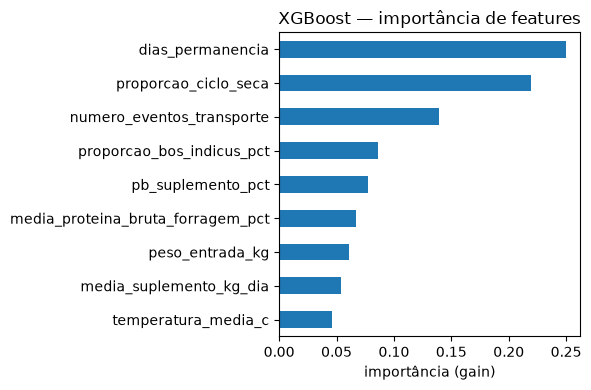

In [7]:
final_model = make_best()
final_model.fit(df[d["scale_cols"]], df[dp.TARGET])
imp = pd.Series(final_model.feature_importances_, index=d["scale_cols"]).sort_values()
fig, ax = plt.subplots(figsize=(6, 4))
imp.plot.barh(ax=ax)
ax.set_xlabel("importância (gain)"); ax.set_title("XGBoost — importância de features")
plt.tight_layout(); plt.show()

## 6. Predito × real (OOF)

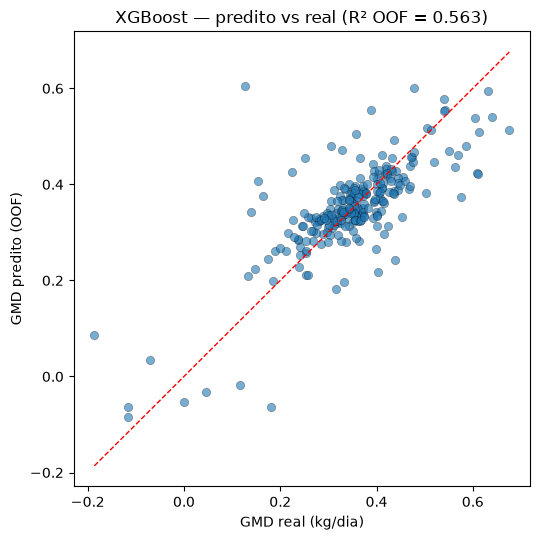

In [8]:
y_true = df[dp.TARGET].values
y_oof = sk_eval.oof(d, make_best, scale=False)
r2_oof = dp.metrics(y_true, y_oof)["R2"]

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(y_true, y_oof, alpha=0.6, edgecolor="k", linewidth=.3)
lims = [min(y_true.min(), y_oof.min()), max(y_true.max(), y_oof.max())]
ax.plot(lims, lims, "r--", lw=1)
ax.set_xlabel("GMD real (kg/dia)"); ax.set_ylabel("GMD predito (OOF)")
ax.set_title(f"XGBoost — predito vs real (R² OOF = {r2_oof:.3f})")
plt.tight_layout(); plt.show()

## 7. Notas

- Grid seleciona por R² média nos 5 folds de 49 de teste — mesmo critério da DNN.
- Mesmo `get_cv()`/`leave_one_property_out` — comparação direta em `results/model_comparison.csv`.